1. 📦 Instalación y Librerías
Primero instalamos y cargamos todas las librerías necesarias para el proyecto.

pandas: manejo y análisis de datos tabulares
numpy: operaciones matemáticas y vectoriales
matplotlib / seaborn: visualización de datos
scikit-learn: herramientas de Machine Learning (regresión, métricas, etc.)
scipy: estadísticas avanzadas

In [ ]:
# ── Importación de librerías ──

import pandas as pd                        # Manejo de datos (DataFrames)
import numpy as np                         # Cálculos numéricos
import matplotlib.pyplot as plt            # Gráficos base
import seaborn as sns                      # Gráficos estadísticos más bonitos

from scipy import stats                    # Pruebas estadísticas

# Scikit-learn: herramientas de Machine Learning
from sklearn.linear_model import LinearRegression   # Modelo de regresión lineal
from sklearn.model_selection import train_test_split # Dividir datos en entrenamiento/prueba
from sklearn.metrics import (                        # Métricas de evaluación
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings('ignore')          # Silenciar advertencias menores

# Estilo visual de los gráficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print('✅ Librerías cargadas correctamente.')

✅ Librerías cargadas correctamente.


## 2. 📂 Carga del Dataset

In [ ]:
from google.colab import files
import io

print('Por favor, selecciona el archivo CSV desde tu PC.')
uploaded = files.upload()

# Obtener el nombre del archivo subido
file_name = next(iter(uploaded))

# Leer el CSV en un DataFrame de pandas
# Asumimos que es el mismo archivo 'student-mat.csv' y usa ';' como separador
df = pd.read_csv(io.StringIO(uploaded[file_name].decode('utf-8')), sep=';')

print(f'✅ Dataset "{file_name}" cargado correctamente.')
print(f'   Filas: {df.shape[0]} | Columnas: {df.shape[1]}')

Por favor, selecciona el archivo CSV desde tu PC.


Saving student-mat.csv to student-mat.csv
✅ Dataset "student-mat.csv" cargado correctamente.
   Filas: 395 | Columnas: 33


In [ ]:
pd.set_option('display.max_columns', None)
display(df.head())

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10


## 3. 🔎 Exploración y Preparación de Datos

Primero, vamos a examinar los tipos de datos y los valores únicos de cada columna para entender mejor el dataset y decidir qué columnas son relevantes para una regresión lineal múltiple. Luego, renombraremos las columnas clave a español y binarizaremos aquellas con solo dos valores.

In [ ]:
print('Información general del DataFrame:')
df.info()

print('\nNúmero de valores únicos por columna:')
print(df.nunique())

Información general del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395

In [ ]:
columns_to_drop_requested = [
    'school', 'address', 'Mjob', 'Fjob', 'reason', 'guardian',
    'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
    'higher', 'romantic', 'famrel', 'Dalc', 'Walc'
]

# Filtrar las columnas que realmente existen en el DataFrame
columns_to_drop_existing = [col for col in columns_to_drop_requested if col in df.columns]

if columns_to_drop_existing:
    df = df.drop(columns=columns_to_drop_existing)
    print('✅ Columnas eliminadas correctamente:', columns_to_drop_existing)
else:
    print('ℹ️ Ninguna de las columnas solicitadas se encontró en el DataFrame o ya fueron eliminadas.')

print('\nLas columnas restantes en el DataFrame son:')
display(df.head())

✅ Columnas eliminadas correctamente: ['school', 'address', 'Mjob', 'Fjob', 'reason', 'guardian', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'romantic', 'famrel', 'Dalc', 'Walc']

Las columnas restantes en el DataFrame son:


,sex,age,famsize,Pstatus,Medu,Fedu,traveltime,studytime,internet,freetime,goout,health,absences,G1,G2,G3
0,F,18,GT3,A,4,4,2,2,no,3,4,3,6,5,6,6
1,F,17,GT3,T,1,1,1,2,yes,3,3,3,4,5,5,6
2,F,15,LE3,T,1,1,1,2,yes,3,2,3,10,7,8,10
3,F,15,GT3,T,4,2,1,3,yes,2,2,5,2,15,14,15
4,F,16,GT3,T,3,3,1,2,no,3,2,5,4,6,10,10


**CODIFICACION DE 0 Y 1 PARA VARIABLES CATEGORICAS**


In [ ]:
# Cambiar 'sex': 0 para F, 1 para M
df['sex'] = df['sex'].replace({'F': 0, 'M': 1})

# Cambiar 'famsize': 0 para GT3, 1 para LE3
df['famsize'] = df['famsize'].replace({'GT3': 0, 'LE3': 1})

# Cambiar 'Pstatus': 0 para A, 1 para T
df['Pstatus'] = df['Pstatus'].replace({'A': 0, 'T': 1})

# Cambiar 'internet': 0 para no, 1 para yes
df['internet'] = df['internet'].replace({'no': 0, 'yes': 1})

print('✅ Columnas transformadas correctamente.')
print('\nLas primeras filas de la tabla con los nuevos valores son:')
display(df.head())

✅ Columnas transformadas correctamente.

Las primeras filas de la tabla con los nuevos valores son:


,sex,age,famsize,Pstatus,Medu,Fedu,traveltime,studytime,internet,freetime,goout,health,absences,G1,G2,G3
0,0,18,0,0,4,4,2,2,0,3,4,3,6,5,6,6
1,0,17,0,1,1,1,1,2,1,3,3,3,4,5,5,6
2,0,15,1,1,1,1,1,2,1,3,2,3,10,7,8,10
3,0,15,0,1,4,2,1,3,1,2,2,5,2,15,14,15
4,0,16,0,1,3,3,1,2,0,3,2,5,4,6,10,10


## 4. ⚙️ Preparación para el Modelo de Regresión Lineal (Nueva Iteración)

Vamos a preparar el conjunto de datos para esta nueva iteración del modelo de regresión lineal, utilizando las variables solicitadas sin renombrarlas. Definiremos la variable objetivo (`y`) como `G3` y las variables predictoras (`X`) con los nombres originales.

In [ ]:
# Definir la variable objetivo (y) y las características (X) según la solicitud del usuario
y = df['G3']
X = df[['Medu', 'Fedu', 'sex', 'studytime', 'internet', 'G1', 'G2']]

print(f'Variables predictoras (X) tienen {X.shape[1]} columnas y {X.shape[0]} filas.')
print(f'Variable objetivo (y) tiene {y.shape[0]} filas.')
display(X.head())
display(y.head())

Variables predictoras (X) tienen 7 columnas y 395 filas.
Variable objetivo (y) tiene 395 filas.


,Medu,Fedu,sex,studytime,internet,G1,G2
0,4,4,0,2,0,5,6
1,1,1,0,2,1,5,5
2,1,1,0,2,1,7,8
3,4,2,0,3,1,15,14
4,3,3,0,2,0,6,10


,G3
0,6
1,6
2,10
3,15
4,10


### 4.1. 📊 División del Conjunto de Datos (Nueva Iteración)

Dividiremos nuestros datos en conjuntos de entrenamiento y prueba. Esto es fundamental para evaluar el rendimiento de nuestro modelo con datos no vistos. Utilizaremos un 20% de los datos para la prueba.

In [ ]:
# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Tamaño del conjunto de entrenamiento X: {X_train.shape}')
print(f'Tamaño del conjunto de prueba X: {X_test.shape}')
print(f'Tamaño del conjunto de entrenamiento y: {y_train.shape}')
print(f'Tamaño del conjunto de prueba y: {y_test.shape}')

Tamaño del conjunto de entrenamiento X: (316, 7)
Tamaño del conjunto de prueba X: (79, 7)
Tamaño del conjunto de entrenamiento y: (316,)
Tamaño del conjunto de prueba y: (79,)


## 5. 🛠️ Construcción y Evaluación del Modelo de Regresión Lineal (Nueva Iteración)

Ahora vamos a construir nuestro modelo de regresión lineal con las nuevas variables, entrenarlo con los datos de entrenamiento y evaluar su rendimiento utilizando métricas comunes, incluyendo MAPE y un histograma de errores.

### 5.1. ⚙️ Entrenamiento del Modelo

In [ ]:
# Instanciar el modelo de Regresión Lineal
model = LinearRegression()

# Entrenar el modelo con los datos de entrenamiento
model.fit(X_train, y_train)

print('✅ Modelo de Regresión Lineal entrenado correctamente.')

✅ Modelo de Regresión Lineal entrenado correctamente.


### 5.2. 📈 Predicciones

In [ ]:
# Realizar predicciones sobre el conjunto de prueba
y_pred = model.predict(X_test)

print('✅ Predicciones realizadas correctamente.')

✅ Predicciones realizadas correctamente.


### 5.3. 📊 Evaluación del Modelo (con MAPE y Histograma de Errores)

In [ ]:
# ==============================
# MÉTRICAS DE EVALUACIÓN
# ==============================
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# ==============================
# MAPE CORREGIDO (sin ceros)
# ==============================
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)

    mask = y_true != 0  # evitar división por cero

    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

mape = mean_absolute_percentage_error(y_test, y_pred)

# ==============================
# RESULTADOS
# ==============================
print(f'Error Absoluto Medio (MAE): {mae:.2f}')
print(f'Error Cuadrático Medio (MSE): {mse:.2f}')
print(f'Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f}')
print(f'Coeficiente de Determinación (R2): {r2:.2f}')
print(f'Error Porcentual Absoluto Medio (MAPE): {mape:.2f}%')

Error Absoluto Medio (MAE): 1.25
Error Cuadrático Medio (MSE): 4.18
Raíz del Error Cuadrático Medio (RMSE): 2.04
Coeficiente de Determinación (R2): 0.80
Error Porcentual Absoluto Medio (MAPE): 9.53%


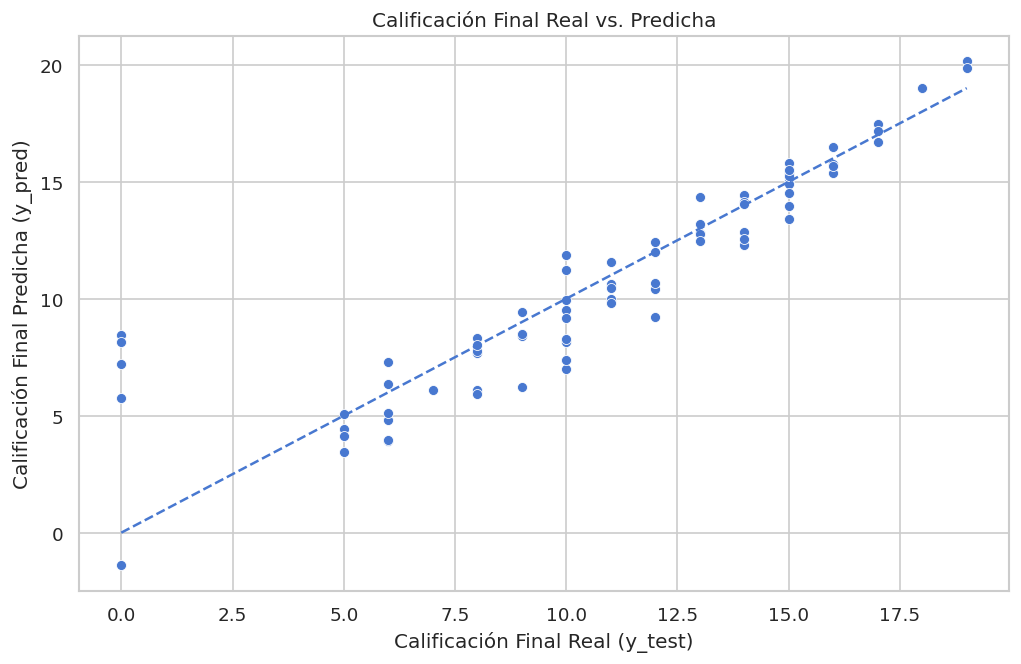

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)

plt.xlabel('Calificación Final Real (y_test)')
plt.ylabel('Calificación Final Predicha (y_pred)')
plt.title('Calificación Final Real vs. Predicha')

# Línea ideal
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')

plt.show()

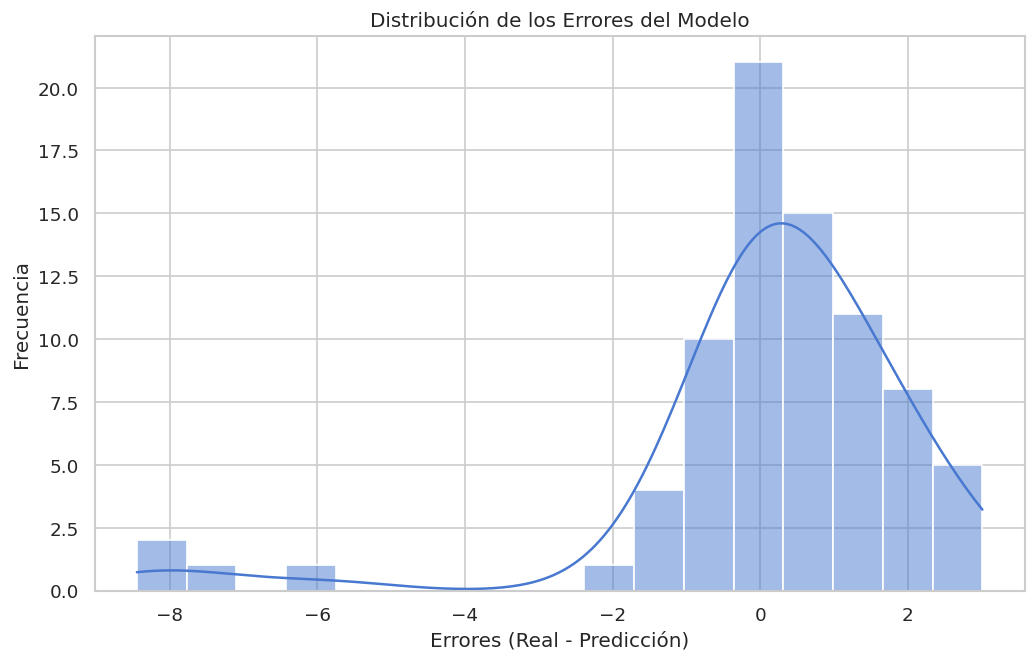

In [ ]:
errors = y_test - y_pred

plt.figure(figsize=(10, 6))
sns.histplot(errors, kde=True)

plt.title('Distribución de los Errores del Modelo')
plt.xlabel('Errores (Real - Predicción)')
plt.ylabel('Frecuencia')

plt.show()

### 5.4. 🔎 Análisis de Coeficientes del Modelo

In [ ]:
# Obtener los coeficientes del modelo
coefficients = model.coef_

# Obtener los nombres de las características
features = X.columns

# Crear un DataFrame para visualizar los coeficientes
coefficients_df = pd.DataFrame({
    'Característica': features,
    'Coeficiente': coefficients
})

# Ordenar por el valor absoluto del coeficiente para ver los más influyentes
coefficients_df['Abs_Coeficiente'] = np.abs(coefficients_df['Coeficiente'])
coefficients_df = coefficients_df.sort_values(by='Abs_Coeficiente', ascending=False).drop(columns='Abs_Coeficiente')

print('✅ Coeficientes del modelo de Regresión Lineal:')
display(coefficients_df)

✅ Coeficientes del modelo de Regresión Lineal:


,Característica,Coeficiente
6,G2,0.988392
0,Medu,0.184022
5,G1,0.165841
1,Fedu,-0.136868
4,internet,-0.127154
2,sex,0.119431
3,studytime,-0.044690


### 5.5. 📊 Matriz de Correlación

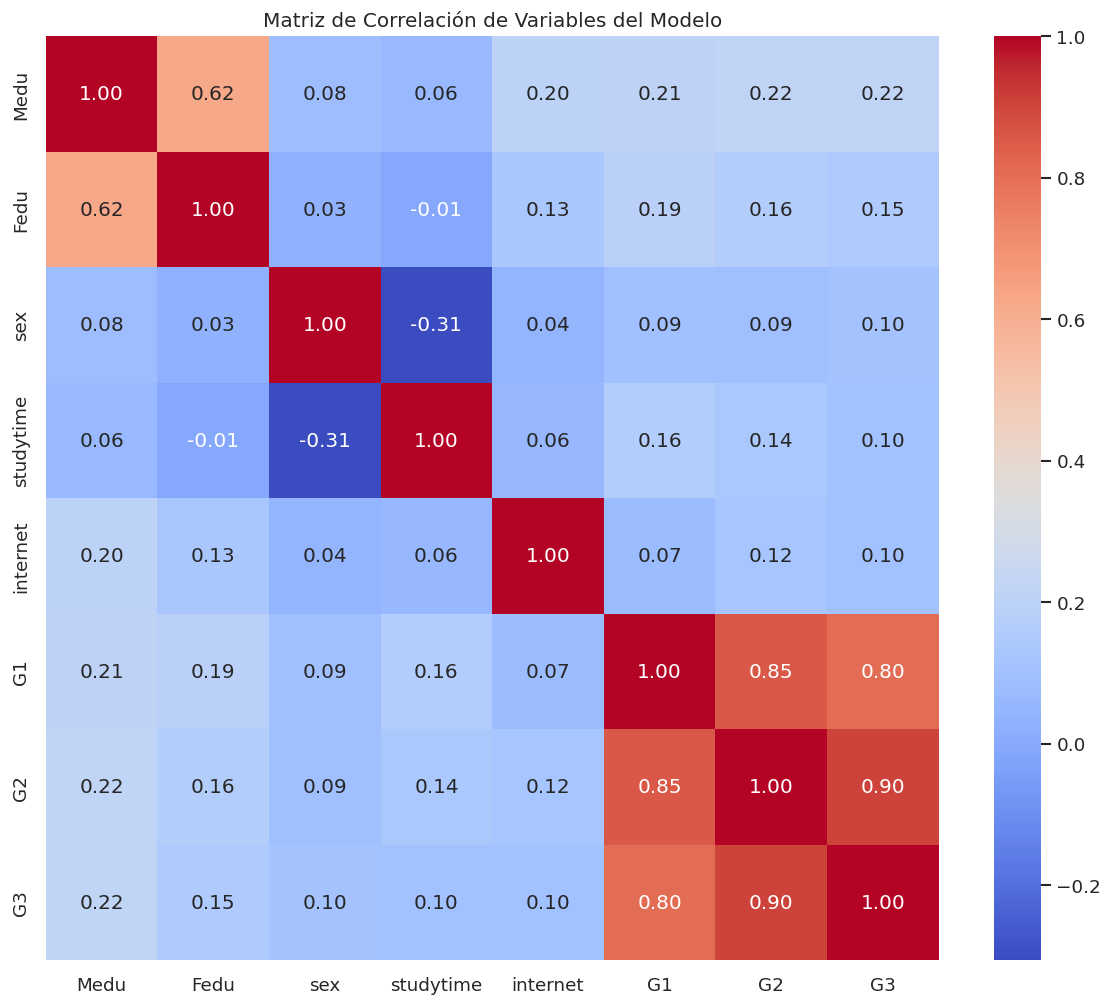

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Concatenar las variables predictoras (X) y la variable objetivo (y) para la correlación
df_model_vars = pd.concat([X, y], axis=1)

plt.figure(figsize=(12, 10))
sns.heatmap(df_model_vars.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación de Variables del Modelo')
plt.show()